In [ ]:
import boto3
import pandas as pd
import io

MY_BUCKET = 'dsan6000-rk1310'  
S3_PREFIX = 'wikipedia-hourly/'

s3 = boto3.client('s3')

# list all parquet files inside the folder 
response = s3.list_objects_v2(Bucket=MY_BUCKET, Prefix=S3_PREFIX)

df_list = []

for obj in response.get('Contents', []):
    file_key = obj['Key']
    
    if file_key.endswith('.parquet'):
        print(f"Reading {file_key} from S3...")
        
        # downlaod from s3
        file_obj = s3.get_object(Bucket=MY_BUCKET, Key=file_key)
        parquet_buffer = io.BytesIO(file_obj['Body'].read())
        
        # create df 
        hourly_df = pd.read_parquet(parquet_buffer)
        df_list.append(hourly_df)



# combine into one giant df 
if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print("\nData loading complete!")
    print(f"DataFrame shape: {df.shape}")
    
    # display the first few rows now that data is successfully loaded
    print(df.head(30))
else:
    print("no Parquet files found in the specified S3 path. Check your prefix or bucket name.")


Reading wikipedia-hourly/20260901_040000.parquet from S3...
Reading wikipedia-hourly/20260901_050000.parquet from S3...
Reading wikipedia-hourly/20260901_060000.parquet from S3...
Reading wikipedia-hourly/20260901_070000.parquet from S3...
Reading wikipedia-hourly/20260901_080000.parquet from S3...
Reading wikipedia-hourly/20260901_090000.parquet from S3...
Reading wikipedia-hourly/20260901_100000.parquet from S3...
Reading wikipedia-hourly/20260901_110000.parquet from S3...
Reading wikipedia-hourly/20260901_120000.parquet from S3...
Reading wikipedia-hourly/20260901_130000.parquet from S3...
Reading wikipedia-hourly/20260901_140000.parquet from S3...
Reading wikipedia-hourly/20260901_150000.parquet from S3...
Reading wikipedia-hourly/20260901_160000.parquet from S3...
Reading wikipedia-hourly/20260901_170000.parquet from S3...
Reading wikipedia-hourly/20260901_180000.parquet from S3...
Reading wikipedia-hourly/20260901_190000.parquet from S3...
Reading wikipedia-hourly/20260901_200000

In [17]:
print(df.columns)


Index(['datetime', '$schema', 'meta', 'id', 'type', 'namespace', 'title',
       'title_url', 'comment', 'timestamp', 'user', 'bot', 'notify_url',
       'minor', 'length', 'revision', 'server_url', 'server_name',
       'server_script_path', 'wiki', 'parsedcomment', 'log_id', 'log_type',
       'log_action', 'log_params', 'log_action_comment', 'patrolled',
       'file_ts', 'file_ts_str', 'hour'],
      dtype='str')


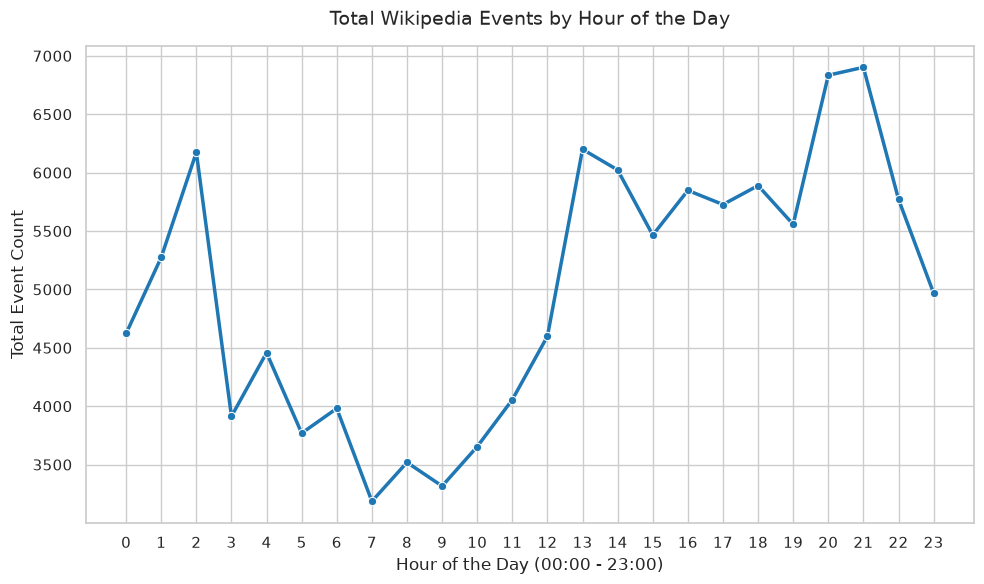

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# made images directory to store plots 

# convert to datetime
df['timestamp'] = pd.to_datetime(df['datetime'])

# pull hour from datetime col 
df['hour'] = df['timestamp'].dt.hour


# aggretate by events per hour 

hourly_counts = df.groupby('hour').size().reset_index(name='total_events')

# plot #1 
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

# lineplot 
sns.lineplot(
    data=hourly_counts, 
    x='hour', 
    y='total_events', 
    marker='o', 
    color='tab:blue', 
    linewidth=2.5
)

# labels 
plt.title('Total Wikipedia Events by Hour of the Day', fontsize=14, pad=15)
plt.xlabel('Hour of the Day (00:00 - 23:00)', fontsize=12)
plt.ylabel('Total Event Count', fontsize=12)
plt.xticks(range(0, 24)) 
plt.tight_layout()

# export file format 
plt.savefig('images/hourly-events.svg', format='svg', dpi=300)
plt.savefig('images/hourly-events.png', format='png', dpi=300)

plt.show()


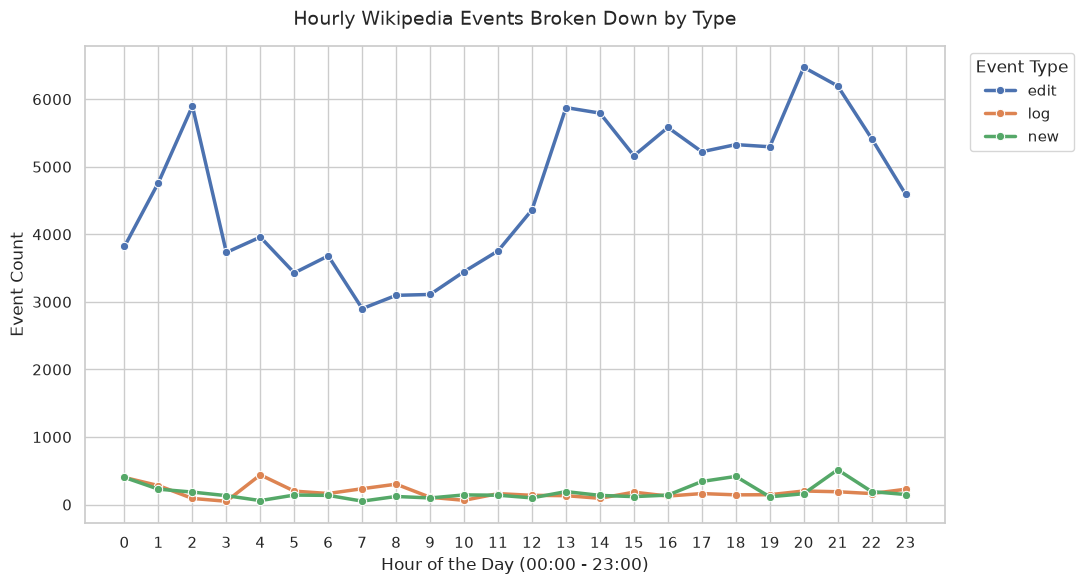

In [19]:
# plot #2 


# aggregate event type by hour 
hourly_type_counts = df.groupby(['hour', 'type']).size().reset_index(name='event_count')

# make plot 
sns.set_theme(style='whitegrid')
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=hourly_type_counts, 
    x='hour', 
    y='event_count', 
    hue='type',  
    marker='o', 
    linewidth=2.5
)

# axis and labels 
plt.title('Hourly Wikipedia Events Broken Down by Type', fontsize=14, pad=15)
plt.xlabel('Hour of the Day (00:00 - 23:00)', fontsize=12)
plt.ylabel('Event Count', fontsize=12)
plt.xticks(range(0, 24)) 
plt.legend(title='Event Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# export 
plt.savefig('images/events-by-type.svg', format='svg', dpi=300)
plt.savefig('images/events-by-type.png', format='png', dpi=300)
plt.show()
